# t0207: Elsys tpc5 + NI npz → Labquake Explorer HDF5

Preprocessing for an experiment recorded on two systems.

* **Elsys TranAX** (`.tpc5`, ECR dual mode): block 1 is a 2 kHz continuous record of the
  whole run, blocks 2…N are 2 MHz records around each PZT trigger (0.1 s before, 0.5 s after).
* **National Instruments USB-6451** (`.npz`, run5 only): the mechanical channels recorded
  continuously at 500 kHz on the NI clock, with `trigger_sample_index` marking the sample at
  which the first Elsys trigger pulse arrived (the Elsys only emits that pulse once).

Runs 1–4 had every sensor on the Elsys and use the tpc5-only recipe of `t0211_tpc5.ipynb`.
In run5 the mechanical sensors were moved to the NI logger (the Elsys channels A5–A7 and
B1–B8 read 0 V), so that run's time history is the NI record decimated to 2 kHz, on the NI
clock, with the Elsys PZTs interpolated onto it; both files stay referenced for event
extraction, the Elsys one shifted by `elsys.time_offset`.

Run sheet (2026-08-20, 21 °C, 57 % RH, flow rate 8 ml/min, operators 朱宸潁、張德權):

| Elsys channel | sensor        | input range (Elsys setting) |
|---------------|---------------|-----------------------------|
| A1–A4         | PZT           | ±0.25 V                     |
| A5, A6        | pressure      | 0–10 V                      |
| A7            | LVDT          | −6 to 14 V                  |
| B1–B8         | eddy current  | ±25 V                       |

NI channels (research log "[T207] NI-6451 DAQ Trial Run", 2026-08-20): AI-0 normal-stress
voltage, AI-1 shear-stress voltage, AI-2 LVDT, AI-3 an eddy-current sensor with a 9 V dry cell
in series as an offset trial (it reads about 9 V above the others), AI-4 to AI-10 the usual
eddy-current sensors; ±10 V input range, which is narrower than the eddy sensors' −25 to 0 V
output (run5 reaches −9.8 V without clipping). Remark on the run sheet: after run2 block 20
the E02 slip channel is suspect.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget

sys.path.insert(0, str(Path.cwd().resolve().parents[1]))   # repository root, if not pip-installed
from labquake_explorer.data.data_manager import DataManager
from labquake_explorer.data.sources import Tpc5Source, NINpzSource, open_source, run_sources
from labquake_explorer.data.channels import get_channel, aligned_fields
from labquake_explorer.preprocessing import (
    Calibration, EddySlip, Linear, Friction, pressure_transducers, experiment,
    run_from_tpc5, run_from_tpc5_ni, slip_step_table,
)

## Paths

NI files are paired with tpc5 files by the `runN` token in their names.

In [2]:
import re

EXPERIMENT = 't0207'
EXPERIMENT_DIR = Path('/Users/hueyke/Library/CloudStorage/SynologyDrive-data/Experiment/T0207')
DATA_DIR = EXPERIMENT_DIR / f'{EXPERIMENT}.exp' / 'data'
OUTPUT_FILE = EXPERIMENT_DIR / f'{EXPERIMENT}.h5'   # raw-file paths are stored relative to it

TPC5_FILES = sorted(DATA_DIR.glob(f'{EXPERIMENT}_*.tpc5'))
NI_FILES = {m.group(1): p for p in DATA_DIR.glob('*.npz') for m in [re.search(r'(run\d+)', p.name)] if m}
run_of = lambda p: re.search(r'(run\d+)', p.stem).group(1)

pd.DataFrame([{'run': run_of(p), 'tpc5': p.name, 'tpc5 (MB)': round(p.stat().st_size / 1e6),
               'ni npz': NI_FILES[run_of(p)].name if run_of(p) in NI_FILES else '',
               'ni (MB)': round(NI_FILES[run_of(p)].stat().st_size / 1e6) if run_of(p) in NI_FILES else ''}
              for p in TPC5_FILES])

,run,tpc5,tpc5 (MB),ni npz,ni (MB)
0,run1,t0207_01_10MPa_run1.tpc5,1140,,
1,run2,t0207_02_12MPa_run2.tpc5,950,,
2,run3,t0207_03_14MPa_run3.tpc5,1180,,
3,run4,t0207_04_16MPa_run4.tpc5,1142,,
4,run5,t0207_04_16MPa_run5.tpc5,497,T0207-raw-run5-20260820_204711.npz,7545


## What is in the files

The NI record and the tpc5 block table of run5 (metadata only).

In [3]:
ni = NINpzSource.open(NI_FILES['run5'])
display(pd.Series({k: v for k, v in ni.record.as_dict().items() if k != 'member_offsets'}))
src5 = Tpc5Source.open(DATA_DIR / 't0207_04_16MPa_run5.tpc5')
display(pd.DataFrame([b.as_dict() for b in src5.blocks]))

format                                                             ni_npz
sample_rate                                                      500000.0
n_samples                                                        85735000
duration_s                                                         171.47
dtype                                                             float64
channels                [ai0, ai1, ai2, ai3, ai4, ai5, ai6, ai7, ai8, ...
labels                                 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
trigger_sample_index                                             14320689
trigger_time                                                    28.641378
dtype: object

,block,sample_rate,n_samples,trigger_sample,trigger_time,start_time,start,end
0,1,2000.0,334404,334403,167.201500,2026-08-20T20:44:22.0000000+08:00,0.000000,167.201500
1,2,2000000.0,1200000,200000,26.252439,2026-08-20T20:44:22.0000000+08:00,26.152439,26.752439
2,3,2000000.0,1200000,200000,41.186889,2026-08-20T20:44:22.0000000+08:00,41.086889,41.686889
3,4,2000000.0,1200000,200000,53.349308,2026-08-20T20:44:22.0000000+08:00,53.249308,53.849308
4,5,2000000.0,1200000,200000,66.635375,2026-08-20T20:44:22.0000000+08:00,66.535375,67.135374
5,6,2000000.0,1200000,200000,78.201488,2026-08-20T20:44:22.0000000+08:00,78.101488,78.701487
6,7,2000000.0,1200000,200000,79.623954,2026-08-20T20:44:22.0000000+08:00,79.523954,80.123954
7,8,2000000.0,1200000,200000,93.042394,2026-08-20T20:44:22.0000000+08:00,92.942394,93.542393
8,9,2000000.0,1200000,200000,111.004811,2026-08-20T20:44:22.0000000+08:00,110.904811,111.504810
9,10,2000000.0,1200000,200000,119.807586,2026-08-20T20:44:22.0000000+08:00,119.707586,120.307585


## Channel roles and calibration

`ELSYS_CHANNELS` and `NI_CHANNELS` map each recorder's channel label to the field stored in the run (volts).
`CALIBRATION` is the list of conversions applied on top; every step is also written
into `run['calibration']` so the file documents how its physical channels were made.

* Stresses: the lab's pressure-transducer calibration for a 1D fault with a 5 cm
  cross-section (Tseng 2026, NTU thesis, Appendix B.3.3 / Table B.1):
  `sigma_n = 4.507 V - 0.410` MPa on A5 and `V = 0.109 tau` on A6. The runs reproduce
  their nominal normal stress within 2 %.
* Slip: the stage calibration of the eddy-current sensors, `d (mm) = slope * V + intercept`,
  gave -94.7, -96.6 and -95.4 um/V for three sensors (R² >= 0.9997, RMSE <= 10 um, travel up
  to 2 mm); their mean, -95.6 um/V, is used for all eight. The jig intercepts are dropped and
  every `slip_k` is zeroed on the first 0.5 s of the run. The
  slope is negative (voltage falls as the gap opens), so slip accumulates positive.
  There is no separate `displacement` field: the views take `slip/slip_1` (or whichever slip
  channel you choose) as the fault slip.
* The LVDT measures the load-point displacement: `LP_displacement = LVDT_UM_PER_V * lvdt`.
  Its slope is still unknown, so `LP_displacement` stays in volts until `LVDT_UM_PER_V` is filled in.

`POSITIONS` places the sensors on the sample in mm. The origin is where the fault, the load-point plane
and the bottom plane meet; +x points along the shear-loading direction, +y opposite to the normal-loading
direction (across the fault), +z up. The eddy-current sensors sit on the fault (y = 0) every 62 mm from
x = 31 mm, the PZTs 100 mm off it; all at mid-height (z = 50). The table is stored with each recorder's
`raw_data` and inherited by `slip` and by the `waveform` records of extracted events.

Layout of each run: `time`; one block per recorder (`elsys`, and `ni` for run5) holding the
raw-file reference and that recorder's voltages as the channel array `raw_data` (`data`
(channels x samples), `channels`, `unit`, `positions`); the physical scalars `normal_stress`,
`shear_stress`, `friction`, `LP_displacement` at the top level; `slip` (channel array `slip_1..8`
in um with `source`, `slope_mm_per_v` and `positions`); `units`, `calibration`, `sources`.

`EVENT_FIELDS` says which Elsys channels **Extract Events** copies into an event's
`waveform`: the whole 2 MHz trigger block that contains the event time (and overlaps the
chosen window most), the PZTs by default.


`NI_DECIMATION` is the block-mean factor for the run's time history (500 kHz → 2 kHz); the
full-rate record stays reachable through `run['ni']`.

In [4]:
ELSYS_CHANNELS = {    # Elsys channel -> field (volts)
    'A1': 'pzt_1',
    'A2': 'pzt_2',
    'A3': 'pzt_3',
    'A4': 'pzt_4',
    'A5': 'pressure_1',   # normal-stress transducer
    'A6': 'pressure_2',   # shear-stress transducer
    'A7': 'lvdt',
    'B1': 'eddy_1',
    'B2': 'eddy_2',
    'B3': 'eddy_3',
    'B4': 'eddy_4',
    'B5': 'eddy_5',
    'B6': 'eddy_6',
    'B7': 'eddy_7',
    'B8': 'eddy_8',
}

EDDY_MM_PER_V = -0.09558   # one slope for every sensor: mean of the stage calibration of three sensors
                           # (-0.0947, -0.0966, -0.0954 mm/V, R² >= 0.9997, travel up to 2 mm)
LVDT_UM_PER_V = None       # load-point displacement per volt of LVDT; unknown, so LP_displacement stays in volts

CALIBRATION = Calibration(
    *pressure_transducers('1D-5cm'),                                       # normal_stress, shear_stress (MPa)
    Linear('LP_displacement', 'lvdt', factor=LVDT_UM_PER_V or 1.0,          # load-point displacement from the LVDT
           unit='um' if LVDT_UM_PER_V else 'V'),
    EddySlip({}, default_slope_mm_per_v=EDDY_MM_PER_V, zero_window_s=0.5),                        # slip_1..8 (um)
    Friction(),
    note='pressure: Tseng 2026 Table B.1 (1D, 5 cm); eddy: one slope, mean of the stage calibration of three sensors; '
         'LVDT: slope unknown, LP_displacement in volts',
)

# Sensor positions on the sample (mm). Origin: where the fault, the load-point plane and the bottom plane meet;
# +x along the shear-loading direction, +y opposite to the normal-loading direction (across the fault), +z up.
POSITIONS = {         # field -> (x, y, z)
    'pzt_1': (100, 100, 50),
    'pzt_2': (200, 100, 50),
    'pzt_3': (300, 100, 50),
    'pzt_4': (400, 100, 50),
    'eddy_1': (31, 0, 50),
    'eddy_2': (93, 0, 50),
    'eddy_3': (155, 0, 50),
    'eddy_4': (217, 0, 50),
    'eddy_5': (279, 0, 50),
    'eddy_6': (341, 0, 50),
    'eddy_7': (403, 0, 50),
    'eddy_8': (465, 0, 50),
}
POSITION_FRAME = ('origin at the intersection of the fault, the load-point plane and the bottom plane; '
                  '+x along the shear-loading direction, +y opposite to the normal-loading direction, +z up')

EVENT_FIELDS = ['pzt_1', 'pzt_2', 'pzt_3', 'pzt_4']   # Elsys channels copied into events (whole trigger block)

NI_CHANNELS = {       # NI channel -> field (volts); research log, [T207] NI-6451 DAQ Trial Run (2026-08-20)
    'ai0': 'pressure_1',  # normal-stress transducer
    'ai1': 'pressure_2',  # shear-stress transducer
    'ai2': 'lvdt',
    'ai3': 'eddy_1',      # 9 V dry cell in series as an offset trial; the zeroing removes it
    'ai4': 'eddy_2',
    'ai5': 'eddy_3',
    'ai6': 'eddy_4',
    'ai7': 'eddy_5',
    'ai8': 'eddy_6',
    'ai9': 'eddy_7',
    'ai10': 'eddy_8',
}
NI_META = {
    'channel_notes': {'ai3': '9 V dry cell wired in series before the DAQ (offset trial)'},
    'input_range_v': 10.0,
}
NI_DECIMATION = 250            # 500 kHz -> 2 kHz
NI_EVENT_WINDOW_S = (0.1, 0.5)  # full-rate NI samples copied into each event (all NI channels)
ALIGNMENT_FIELD = 'eddy_5'     # NI channel with the clearest slip steps (ai7)

## Read the runs

Runs with an NI file take the NI clock as the run clock; the Elsys offset comes from the NI trigger sample and the first Elsys trigger block.

In [5]:
runs = []
for p in TPC5_FILES:
    if run_of(p) in NI_FILES:
        runs.append(run_from_tpc5_ni(p, NI_FILES[run_of(p)], ELSYS_CHANNELS, NI_CHANNELS, OUTPUT_FILE.parent,
                                     CALIBRATION, ni_decimation=NI_DECIMATION, ni_meta=NI_META,
                                     elsys_event_fields=EVENT_FIELDS,
                                     ni_event_window_s=NI_EVENT_WINDOW_S,
                                     positions=POSITIONS, position_frame=POSITION_FRAME))
    else:
        runs.append(run_from_tpc5(p, ELSYS_CHANNELS, OUTPUT_FILE.parent, CALIBRATION,
                                  event_fields=EVENT_FIELDS,
                                  positions=POSITIONS, position_frame=POSITION_FRAME))
pd.DataFrame([{
    'name': r['name'], 'source': ' + '.join(ref['format'] for ref in run_sources(r).values()),
    'sigma_n nominal (MPa)': r['normal_stress_level'], 'sigma_n measured (MPa)': float(np.nanmean(r['normal_stress'])),
    'samples': r['time'].size, 'duration (s)': float(r['time'][-1] - r['time'][0]),
    'trigger blocks': len(r['elsys']['blocks']['block']),
    'Elsys -> run offset (s)': r['elsys']['time_offset'], 'slip_1 end (um)': float(get_channel(r, 'slip_1')[-1]),
} for r in runs])

,name,source,sigma_n nominal (MPa),sigma_n measured (MPa),samples,duration (s),trigger blocks,Elsys -> run offset (s),slip_1 end (um)
0,run1,tpc5,10.0,10.203327,647372,323.6855,30,0.000000,1472.739624
1,run2,tpc5,12.0,12.077213,506288,253.1435,25,0.000000,1154.094727
2,run3,tpc5,14.0,13.966683,693820,346.9095,31,0.000000,1565.486328
3,run4,tpc5,16.0,15.758996,694204,347.1015,30,0.000000,1573.264893
4,run5,ni_npz + tpc5,16.0,15.398606,342940,171.4695,13,2.388939,684.026550


## Clock check for run5

For every Elsys trigger, the largest 20 ms change of one NI eddy-current channel within
±1 s of the shifted trigger time. Slip must follow the PZT trigger by tens of milliseconds,
never precede it; triggers without a step are PZT-only events.

In [6]:
run5 = next(r for r in runs if 'ni' in r)
ni_src = open_source(run5['ni'], OUTPUT_FILE.parent, run5)
alignment = pd.DataFrame(slip_step_table(ni_src, run5['elsys']['blocks']['trigger_time_run'], ALIGNMENT_FIELD,
                                         decimation=NI_DECIMATION))
display(alignment)
lags = alignment['lag_ms'].dropna()
print(f"offset {run5['elsys']['time_offset']:.4f} s; slip steps for {lags.size} of {len(alignment)} triggers; "
      f"lag after the PZT trigger: {lags.min():.0f}..{lags.max():.0f} ms" if lags.size else 'no slip steps found')

,t_run,slip_step,step_t_run,lag_ms,dV,note
0,28.641378,False,NaN,NaN,-0.004633,
1,43.575828,True,43.604577,28.7490,-0.054990,
2,55.738247,True,55.893497,155.2500,-0.926736,
3,69.024314,True,69.117563,93.2495,-0.714149,
4,80.590426,False,NaN,NaN,-0.014665,
5,82.012893,False,NaN,NaN,-0.007554,
6,95.431332,False,NaN,NaN,-0.010174,
7,113.393749,True,113.440999,47.2495,-1.083249,
8,122.196524,True,122.348273,151.7485,-0.434824,
9,128.780016,False,NaN,NaN,-0.010551,


offset 2.3889 s; slip steps for 6 of 13 triggers; lag after the PZT trigger: 29..155 ms


## Overview

Stresses and the mean slip of every run; shaded spans are the Elsys trigger blocks on the run's clock.

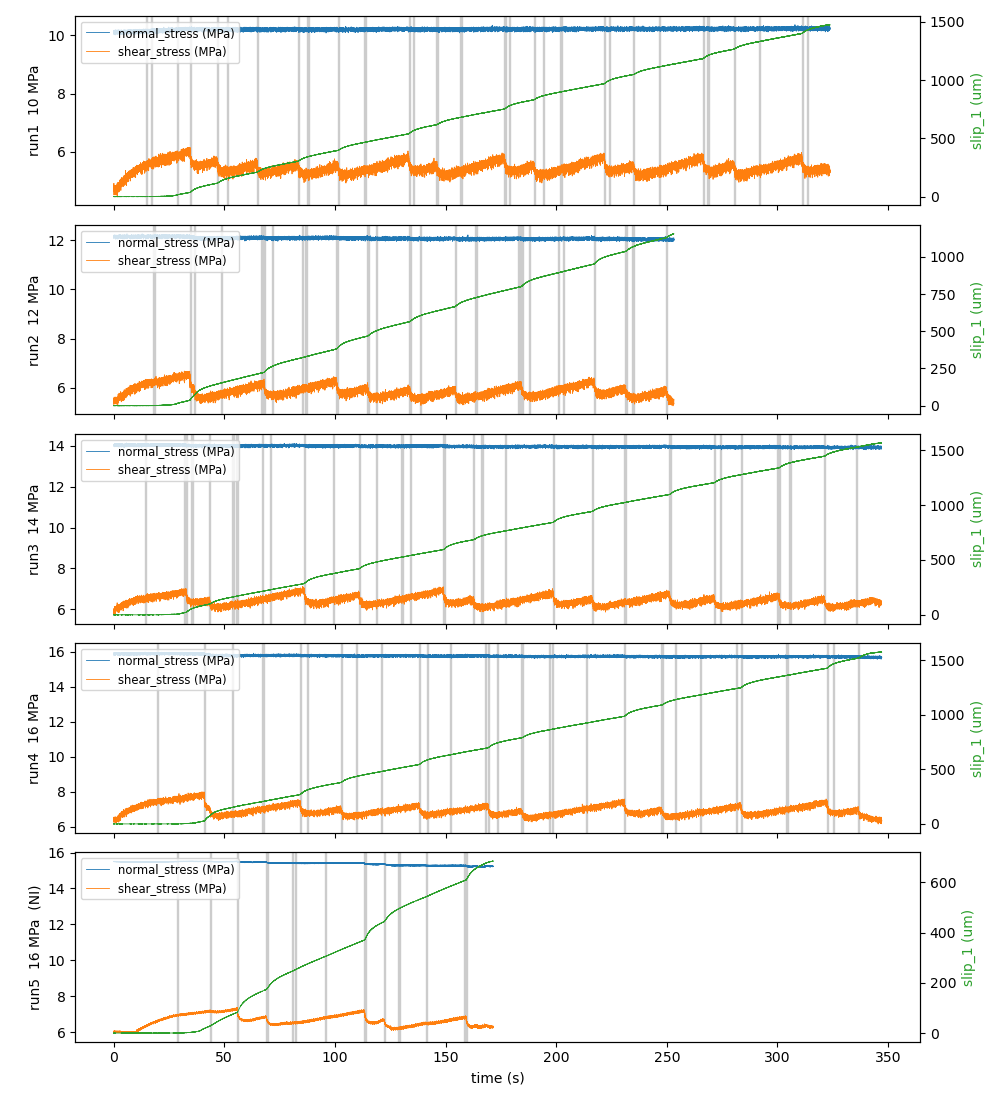

In [7]:
fig, axs = plt.subplots(len(runs), 1, figsize=(10, 2.2 * len(runs)), sharex=True)
for ax, run in zip(np.atleast_1d(axs), runs):
    ax.plot(run['time'], run['normal_stress'], lw=0.6, label='normal_stress (MPa)')
    ax.plot(run['time'], run['shear_stress'], lw=0.6, label='shear_stress (MPa)')
    ax2 = ax.twinx()
    ax2.plot(run['time'], get_channel(run, 'slip_1'), lw=0.6, color='C2')
    ax2.set_ylabel('slip_1 (um)', color='C2')
    blocks, dt0 = run['elsys']['blocks'], run['elsys']['time_offset']
    for a, b in zip(blocks['start'], blocks['end']):
        ax.axvspan(a + dt0, b + dt0, color='0.8', zorder=-10)
    ax.set_ylabel(f"{run['name']}  {run['normal_stress_level']:g} MPa" + ('  (NI)' if 'ni' in run else ''))
    ax.legend(loc='upper left', fontsize='small')
axs[-1].set_xlabel('time (s)')
fig.tight_layout()

## Run5: NI slip against Elsys triggers

Text(0.5, 1.0, 'run5: eddy-current slip vs Elsys PZT triggers (dotted) after the clock shift')

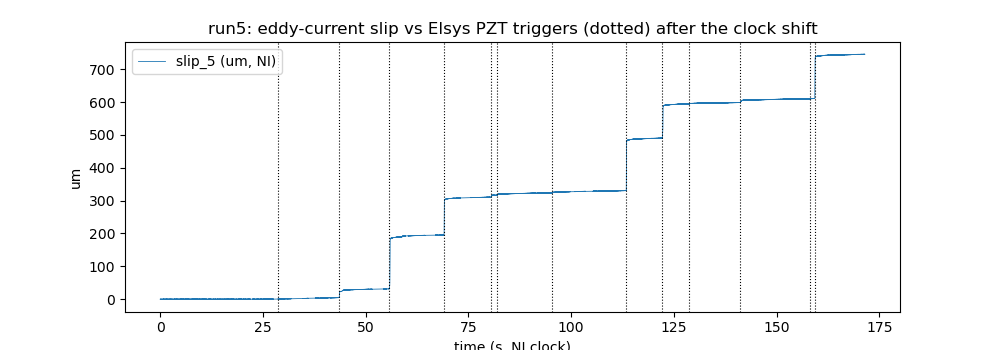

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(run5['time'], get_channel(run5, ALIGNMENT_FIELD.replace('eddy', 'slip')), lw=0.6, label=f"{ALIGNMENT_FIELD.replace('eddy', 'slip')} (um, NI)")
for t in run5['elsys']['blocks']['trigger_time_run']:
    ax.axvline(t, color='k', ls=':', lw=0.8)
ax.set_xlabel('time (s, NI clock)'); ax.set_ylabel('um'); ax.legend(loc='upper left')
ax.set_title('run5: eddy-current slip vs Elsys PZT triggers (dotted) after the clock shift')

## Experiment record and save

In [9]:
EXPERIMENT = experiment(
    't0207', runs,
    date='2026-08-20', operators=['朱宸潁', '張德權'], temperature_C=21.0, humidity_percent=57.0, flow_rate_ml_min=8.0,
    acquisition=('Runs 1-4: Elsys TranAX ECR dual mode, block 1 continuous at 2 kHz, trigger blocks at 2 MHz '
                 '(0.1 s pre, 0.5 s post); A1-A4 PZT, A5-A6 pressure, A7 LVDT, B1-B8 eddy current. '
                 'Run 5: mechanical channels on a National Instruments USB-6451 at 500 kHz (ai0-ai10, '
                 'block means for the time history), PZT on the Elsys; run time axis is the NI clock.'),
    notes='Run sheet: after run2 block 20 the E02 slip channel is suspect.',
)

In [10]:
dm = DataManager()
dm.data = EXPERIMENT
dm.save_file(OUTPUT_FILE)
print(f'{OUTPUT_FILE}  {OUTPUT_FILE.stat().st_size / 1e6:.1f} MB')

/Users/hueyke/Library/CloudStorage/SynologyDrive-data/Experiment/T0207/t0207.h5  108.0 MB


## Check the file the way the explorer loads it

In [11]:
check = DataManager()
check.load_file(OUTPUT_FILE)
rows = []
for run in check.get_data('runs'):
    row = {'run': run['name'], 'samples': len(run['time']),
           'series': len(aligned_fields(run, len(run['time']), recurse=False)),
           'trigger blocks': len(run['elsys']['blocks']['block']),
           'slip_1 end (um)': float(get_channel(run, 'slip_1')[-1])}
    for key, ref in run_sources(run).items():
        row[f'{key} file found'] = (OUTPUT_FILE.parent / ref['filename']).exists()
    rows.append(row)
pd.DataFrame(rows)

,run,samples,series,trigger blocks,slip_1 end (um),elsys file found,ni file found
0,run1,647372,28,30,1472.739624,True,NaN
1,run2,506288,28,25,1154.094727,True,NaN
2,run3,693820,28,31,1565.486328,True,NaN
3,run4,694204,28,30,1573.264893,True,NaN
4,run5,342940,28,13,684.026550,True,True


## Next

Open `t0207.h5` in Labquake Explorer, right-click `runs/[i]/shear_stress` → **Pick Events**: double-click the curve to
place the events, set the window and press **Extract Events**. Each event gets the run's channels around the pick,
`<recorder>/raw_data` (the 2 kHz voltages of the window, as in the run), `waveform/elsys` (the PZTs of the whole 2 MHz trigger
block that contains the event, on the run clock) and, for run5, `waveform/ni` (all NI channels at 500 kHz,
0.1 s before to 0.5 s after the event).